# Support Vector Machine From Scratch and using Sklearn library

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic', 'anagrams', 'anagrams', 'anscombe', 'anscombe', 'attention', 'attention', 'brain_networks', 'brain_networks', 'car_crashes', 'car_crashes', 'diamonds', 'diamonds', 'dots', 'dots', 'dowjones', 'dowjones', 'exercise', 'exercise', 'flights', 'flights', 'fmri', 'fmri', 'geyser', 'geyser', 'glue', 'glue', 'healthexp', 'healthexp', 'iris', 'iris', 'mpg', 'mpg', 'penguins', 'penguins', 'planets', 'planets', 'seaice', 'seaice', 'taxis', 'taxis', 'tips', 'tips', 'titanic', 'titanic', 'anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
df = sns.load_dataset("iris")
df.head()
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


### here we are going to mark the setosa as 1 and all other as -1 for binary classification problem

In [4]:
print(df["species"].unique())
df["species"] = df["species"].str.strip().str.lower()
df["species"] =np.where(df["species"] == "setosa", 1, -1)
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']
[ 1 -1]


# Support Vector Machine for Classification from Scratch

In [5]:
class SupportVectorMachine:
    def __init__(self,lr=0.01,epochs=100,lambda_param=0.01):
        self.weight = None
        self.bias = None
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
    
    def fit(self,X,y):
        n_samples,n_features = X.shape
        y = np.array(y)
        self.weight = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            for index,x_i in enumerate(X):
                condition = y[index]*(np.dot(x_i,self.weight) + self.bias) >= 1
                if(condition):
                    dw = (2*self.lambda_param*self.weight)
                    db = 0
                else:
                    dw= (2*self.lambda_param*self.weight)- (y[index]*x_i)
                    db = -y[index]
                self.weight -= self.lr * dw
                self.bias -= self.lr * db
                
    def predict(self,X):
        y = np.dot(X,self.weight) + self.bias
        return np.sign(y)

In [6]:
X = df.drop("species",axis=1)
y = df["species"].astype(float)
y.unique()

array([ 1., -1.])

In [7]:
print(X.head())
print(y.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: species, dtype: float64


In [8]:
X = X.astype(float).values
y = y.astype(float).values

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [10]:
print(X.dtype)
print(y.dtype)

float64
float64


In [11]:
svr = SupportVectorMachine()
svr.fit(X_train,y_train)
predicted = svr.predict(X_test)
print(predicted)

[ 1. -1. -1.  1. -1. -1. -1. -1.  1. -1.  1. -1. -1. -1.  1.  1. -1.  1.
  1. -1. -1.  1.  1. -1. -1. -1.  1. -1. -1. -1.  1.  1.  1. -1. -1. -1.
 -1.  1.]


In [12]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    log_loss
)

In [13]:
print("Accuracy:", accuracy_score(y_test, predicted))
print("Precision:",precision_score(y_test, predicted))
print("Recall:",recall_score(y_test, predicted))
print("ROC AUC Score:",roc_auc_score(y_test, predicted))
print("ROC Curve:",roc_curve(y_test, predicted))
print("Logloss:",log_loss(y_test, predicted))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC Score: 1.0
ROC Curve: (array([0., 0., 1.]), array([0., 1., 1.]), array([ 2.,  1., -1.]))
Logloss: 2.2204460492503136e-16


In [14]:
print("confusion matrix",confusion_matrix(y_test,predicted))

confusion matrix [[23  0]
 [ 0 15]]


#### We cannot visualize the decision boundary of the 4d data so we will use the two classes for training and then draw the dicision boundary 


In [15]:
X = df.drop(["petal_length","petal_width","species"],axis=1)
y = df["species"]

In [16]:
X.head()

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [17]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: species, dtype: int32

In [18]:
X = X.astype(float).values
y = y.astype(float).values

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y)

In [20]:
svm = SupportVectorMachine()
svm.fit(X_train,y_train)
predicted = svm.predict(X_test)
print(predicted)

[ 1. -1. -1.  1. -1. -1.  1. -1. -1. -1.  1. -1.  1. -1.  1. -1. -1. -1.
 -1. -1. -1.  1. -1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1. -1. -1. -1.
  1. -1.]


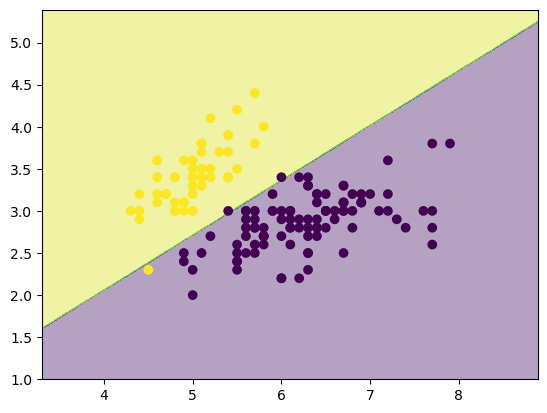

In [21]:
# Step 1: Define limits
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

# Step 2: Create meshgrid
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Step 3: Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Step 4: Predict
Z = svm.predict(grid)

# Step 5: Reshape
Z = Z.reshape(xx.shape)

# Step 6: Plot boundary
plt.contourf(xx, yy, Z, alpha=0.4)

# Step 7: Plot points
plt.scatter(X[:,0], X[:,1], c=y)

plt.show()

# Support Vector Machine for Classification using Sklearn Library

In [22]:
from sklearn.svm import SVC

In [23]:
# Create model
model = SVC()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print(y_pred)

[ 1. -1. -1.  1. -1. -1.  1. -1. -1. -1.  1. -1.  1. -1.  1. -1. -1. -1.
 -1. -1. -1.  1. -1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1. -1. -1. -1.
  1. -1.]


In [24]:
print("Accuracy:", accuracy_score(y_test,y_pred ))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC AUC Score:",roc_auc_score(y_test, y_pred))
print("ROC Curve:",roc_curve(y_test, y_pred))
print("Logloss:",log_loss(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC AUC Score: 1.0
ROC Curve: (array([0., 0., 1.]), array([0., 1., 1.]), array([ 2.,  1., -1.]))
Logloss: 2.2204460492503136e-16


In [25]:
print("confusion matrix",confusion_matrix(y_test,y_pred))

confusion matrix [[28  0]
 [ 0 10]]


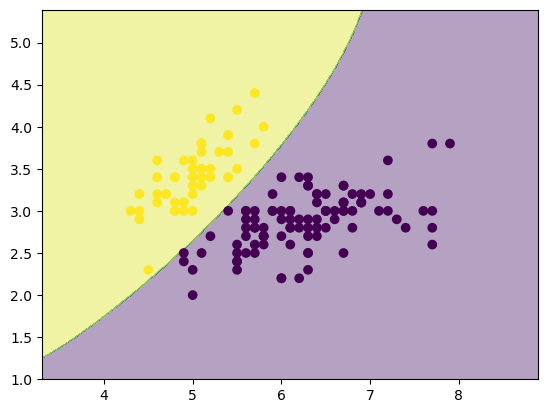

In [26]:
# Step 1: Define limits
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

# Step 2: Create meshgrid
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Step 3: Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Step 4: Predict
Z = model.predict(grid)

# Step 5: Reshape
Z = Z.reshape(xx.shape)

# Step 6: Plot boundary
plt.contourf(xx, yy, Z, alpha=0.4)

# Step 7: Plot points
plt.scatter(X[:,0], X[:,1], c=y)

plt.show()

# Implementation of Support Vector Regression from Scratch

In [27]:
class SVR:

    def __init__(self,
                 learning_rate=0.001,
                 lambda_param=0.01,
                 epsilon=1.0,
                 n_iters=1000,
                 C=1.0):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epsilon = epsilon
        self.n_iters = n_iters
        self.C = C

        self.w = None
        self.b = None

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):

            for idx, x_i in enumerate(X):

                y_pred = np.dot(x_i, self.w) + self.b

                error = y[idx] - y_pred

                # Inside epsilon tube
                if abs(error) <= self.epsilon:

                    dw = self.lambda_param * self.w
                    db = 0

                # Above tube
                elif error > self.epsilon:

                    dw = self.lambda_param * self.w - self.C * x_i
                    db = -self.C

                # Below tube
                else:

                    dw = self.lambda_param * self.w + self.C * x_i
                    db = self.C

                # Update
                self.w = self.w - self.lr * dw
                self.b = self.b - self.lr * db

    def predict(self, X):

        return np.dot(X, self.w) + self.b

In [28]:
# Dataset
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)

y = np.array([2,4,5,4,5,7,8,9])


# Train
model = SVR(
    learning_rate=0.001,
    epsilon=1,
    n_iters=1000,
    C=1
)

model.fit(X, y)

# Predict
predictions = model.predict(X)

print("Weights:", model.w)
print("Bias:", model.b)

Weights: [0.99334446]
Bias: 1.0229999999999981


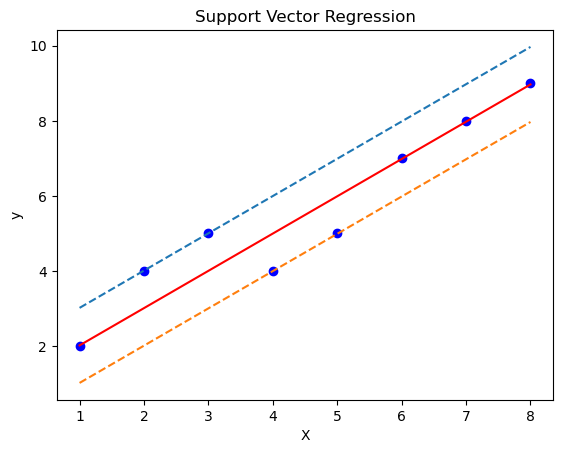

In [29]:
plt.scatter(X, y, color='blue')

plt.plot(X, predictions, color='red')

# Upper epsilon tube
plt.plot(
    X,
    predictions + model.epsilon,
    linestyle='--',
)

# Lower epsilon tube
plt.plot(
    X,
    predictions - model.epsilon,
    linestyle='--',
)

plt.title("Support Vector Regression")

plt.xlabel("X")
plt.ylabel("y")

plt.show()

# Support Vector Regression using Sklearn

In [30]:
from sklearn.svm import SVR

In [31]:
model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma=0.1
)

In [32]:
X = np.array([1,2,3,4,5,6,7,8]).reshape(-1,1)

y = np.array([2,4,5,4,5,7,8,9])

In [33]:
model.fit(X,y)

SVR(C=100, gamma=0.1)

In [34]:
pred = model.predict(X)
print(pred)

[2.10020712 4.09984013 4.63352877 4.43586411 5.10020569 6.68796435
 8.09958188 8.90016515]


In [35]:
pred.reshape(-1,1)

array([[2.10020712],
       [4.09984013],
       [4.63352877],
       [4.43586411],
       [5.10020569],
       [6.68796435],
       [8.09958188],
       [8.90016515]])

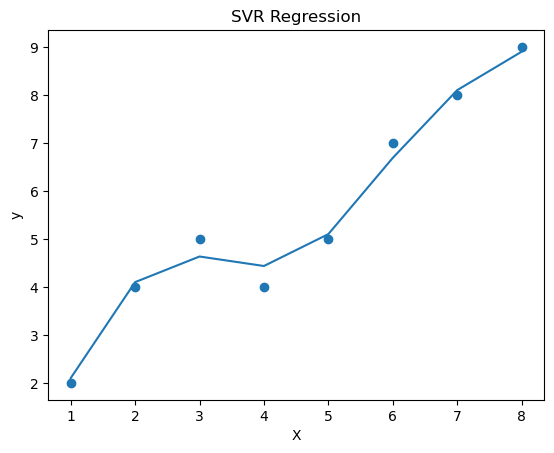

In [36]:
plt.scatter(X, y)

plt.plot(X, pred)

plt.title("SVR Regression")

plt.xlabel("X")
plt.ylabel("y")

plt.show()